# Predictive Feature Analysis & Modeling 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

# Part 1: Feature Exploration & Predictiveness

To start, we conduct an initial exploration of the dataset to determine whether any engineered features exhibit predictive power for short-term price movements.

Before evaluating feature predictiveness, it is better for us to understand the behavior of the underlying price series. Since the dataset consists of high frequency observations, examining the mid price time series helps provide intuition about the market dynamics during the sample period.

By visualizing the mid price, we can observe the general trend and direction of the market over the 7 trading days, the level of volatility and presence of sudden price movements, and whether the data appears stable or exhibits potential regime changes.

This preliminary inspection helps build context for the later analysis.

In [3]:
# Load the dataset
df = pd.read_parquet("feature.parq")

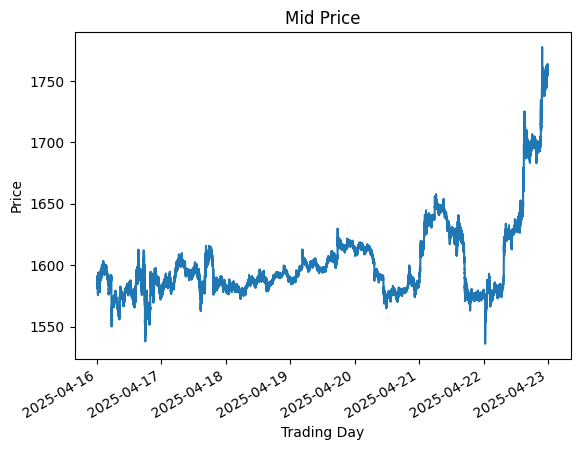

In [4]:
# Plot mid_prc for visualization
df['mid_prc'].plot(title='Mid Price')
plt.xlabel("Trading Day")
plt.ylabel("Price")
plt.title("Mid Price")
plt.show()

The mid-price series exhibits short-term fluctuations with periods of both relatively low and high volatility. While the overall price path shows gradual upward movement during certain intervals. 

This provides context for the subsequent analysis, where we evaluate whether the engineered features contain statistically meaningful information for predicting short-horizon returns.

## Future Return Construction and Feature Selection

To evaluate whether any features contain predictive information, we first define the prediction target. Since price level are non-stationary and strongly autocorrelated, we construct future log returns of the mid price at several prediction horizons. This allows us to measure how well each feature anticipates future price changes rather than the price level itself.

We test multiple short term horizons to understand how predictive power evolves over time. Specifically, we evaluate horizons of **1s, 5s, 10s, 30s, and 60s**, which allows us to examine very short term predictability (microstructure effects), slightly longer horizons where signals may persist, and whether predictive power decays over time.

To measure feature predictiveness, we compute the **Information Coefficient (IC)** between each feature and the future return. IC is defined as Spearman rank correlation between a signal and future returns. Spearman correlation measures the monotonic relationship between variables and is more robust to outliers and nonlinear scaling than Pearson correlation.

We compute two types of IC:
- **Full-sample IC**: The correlation computed across the entire dataset, providing an overall measure of predictive strength.
- **Daily IC**: The correlation computed within each trading day, which helps evaluate whether a signal is stable or inconsistent over time.

Features with higher IC values are considered to have stronger predictive ability and will be candidates for further analysis.

In [5]:
# Define prediction horizons in seconds
horizons = [1, 5, 10, 30, 60]

# Calculate future log returns for each horizon
for h in horizons:
    df[f"ret_{h}s"] = np.log(df["mid_prc"].shift(-h) / df["mid_prc"])

### Feature Scale Check

Before evaluating feature importance, it is useful to examine the scale of the hashed features. If the features are already standardized and bounded within a similar range, then later comparisons based on regression coefficient magnitude become more meaningful.

In [6]:
# Description of dataset
df.describe()

,mid_prc,b66accf4d4,01d830fc33,ac29aa28b0,86eecbe036,9c51f3cf1d,706dbe6d28,cb232e1c9f,301f8d1b44,134e1a6937,...,73762306aa,1c6e322c2d,0d19cb3fb0,486cb65b0c,c49a5f9c65,ret_1s,ret_5s,ret_10s,ret_30s,ret_60s
count,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,...,604378.000000,604378.000000,604378.000000,604378.000000,604378.000000,6.043770e+05,6.043730e+05,604368.000000,604348.000000,604318.000000
mean,1601.856689,-0.001573,0.000471,0.000961,0.000961,-0.003787,-0.004580,-0.002970,-0.003124,0.000960,...,-0.001408,-0.001800,-0.001257,-0.000812,-0.001446,1.660140e-07,8.310267e-07,0.000002,0.000005,0.000010
std,33.063606,1.002640,1.000666,0.999296,0.999296,1.005991,1.007335,1.004184,1.002396,1.061816,...,1.001646,0.966189,1.001703,1.002400,1.001568,1.056672e-04,2.510459e-04,0.000357,0.000620,0.000872
min,1536.010010,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,...,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000,-5.251464e-03,-1.102941e-02,-0.018835,-0.018845,-0.018886
25%,1581.724976,-0.673479,-0.634930,-0.610623,-0.610618,-0.661305,-0.605361,-0.596675,-0.595345,-0.295918,...,-1.011383,-0.636527,-1.028465,-0.621631,-1.004722,0.000000e+00,-8.190014e-05,-0.000132,-0.000250,-0.000359
50%,1591.655029,-0.007083,-0.004322,0.000993,0.001000,-0.003068,-0.006797,0.000932,0.000944,-0.000310,...,0.718494,0.008375,0.769727,0.011204,0.690965,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000006
75%,1612.604980,0.664406,0.633471,0.612619,0.612619,0.654505,0.595105,0.594139,0.592611,0.303442,...,0.947430,0.634845,0.954898,0.628167,0.936125,0.000000e+00,8.248942e-05,0.000134,0.000253,0.000364
max,1777.680054,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,4.331374e-03,7.669054e-03,0.009407,0.019064,0.020278


From the summary statistics above, we observe that the hashed features have:
- Mean approximately 0.
- Standard deviation close to 1.
- Values bounded within the range [-5, 5].

This indicates that the features are already normalized to a comparable scale, which later allows coefficient magnitudes from linear models to serve as a reasonable proxy for relative feature importance.

### Full-sample IC

In [7]:
# Identify feature columns (hash names have 10 character)
feature_cols = [c for c in df.columns if len(c) == 10]

# Compute IC between each feature and future returns for each horizon
ic_results = {}
for h in horizons:
    target = f"ret_{h}s"
    ic = df[feature_cols].corrwith(df[target], method="spearman")
    ic_results[f"{h}s"] = ic

# Convert results to table
ic_table = pd.DataFrame(ic_results)

# Rank features by maximum absolute IC across horizons
ic_table["max_abs_ic"] = ic_table.abs().max(axis=1)
top_features = ic_table.sort_values("max_abs_ic", ascending=False)
print("Top 20 features with highest maximum absolute IC (Full-sample):")
top_features.head(20)

Top 20 features with highest maximum absolute IC (Full-sample):


,1s,5s,10s,30s,60s,max_abs_ic
5e7e5a691e,0.209194,0.116485,0.078534,0.039725,0.028027,0.209194
e10ab80234,0.208954,0.116652,0.078781,0.039931,0.028163,0.208954
5e95d4c57f,0.202927,0.111934,0.073664,0.034574,0.024227,0.202927
ac567aa14a,0.202508,0.112155,0.074000,0.034855,0.024359,0.202508
c12d090869,0.199980,0.107822,0.071358,0.033316,0.023001,0.199980
ec021e3c39,0.199709,0.108281,0.071850,0.033746,0.023411,0.199709
497584e7d1,0.178865,0.093521,0.059243,0.026159,0.018435,0.178865
9c51f3cf1d,0.178774,0.119425,0.082537,0.036275,0.023543,0.178774
865224234b,0.178125,0.093472,0.059346,0.026317,0.018457,0.178125
e093f74611,0.174028,0.089952,0.056582,0.024701,0.017510,0.174028


The table indicates that the features exhibit meaningful predictive power at very short horizons, particularly at 1s and 5s. But, the IC values decrease as the prediction horizon increases. This pattern suggests that the predictive information contained in these features is short lived, with signals being most effective in forecasting immediate price movements. As the horizon extends, the predictive relationship weakens, indicating that the signal decays relatively quickly.

### Daily IC

In [8]:
# Extract date for grouping
df["date"] = df.index.date

# Compute IC for each day separately
daily_ic = {}
for h in horizons:
    target = f"ret_{h}s"
    ic_by_day = df.groupby("date").apply(lambda x: x[feature_cols].corrwith(x[target], method="spearman"), include_groups=False)
    daily_ic[f"{h}s"] = ic_by_day

# Compute mean daily IC for each feature
mean_ic = {h: daily_ic[h].mean() for h in daily_ic}
mean_ic_table = pd.DataFrame(mean_ic)

# Rank features by maximum absolute IC across horizons
mean_ic_table["max_abs_ic"] = mean_ic_table.abs().max(axis=1)
print("Top 20 features with highest maximum absolute IC (Daily):")
mean_ic_table.sort_values("max_abs_ic", ascending=False).head(20)

Top 20 features with highest maximum absolute IC (Daily):


,1s,5s,10s,30s,60s,max_abs_ic
5e7e5a691e,0.219439,0.127012,0.086146,0.043407,0.030574,0.219439
e10ab80234,0.219270,0.126988,0.086211,0.043502,0.030629,0.219270
5e95d4c57f,0.215867,0.124543,0.082289,0.038451,0.026722,0.215867
ac567aa14a,0.215500,0.124445,0.082353,0.038571,0.026744,0.215500
c12d090869,0.211484,0.119364,0.079533,0.037284,0.025690,0.211484
ec021e3c39,0.211329,0.119452,0.079702,0.037518,0.025946,0.211329
497584e7d1,0.189578,0.103649,0.065702,0.028467,0.019802,0.189578
865224234b,0.188964,0.103344,0.065634,0.028538,0.019740,0.188964
9c51f3cf1d,0.188869,0.128530,0.089408,0.038654,0.024851,0.188869
e093f74611,0.184098,0.099502,0.062603,0.026729,0.018708,0.184098


While the full-sample IC measures overall predictive power, it may sometimes be influenced by a small number of strong observations. Therefore, analyzing IC at the daily level helps determine whether the predictive relationship is consistently present across different trading days.

The results are consistent with the full-sample IC analysis, in which the strongest predictive power appears at short horizons, and the IC values decline as the prediction horizon increases. This consistency suggests that the observed predictiveness is not driven by a single period, but rather reflects a more stable relationship between the features and short-term future returns.

## Feature Correlation & Filtering

The next step is to construct a set of features for modeling. We begin by selecting the top 30 features ranked by absolute IC. Starting with a larger candidate set allows us to retain potentially useful features while performing additional filtering steps. However, many features might be highly correlated, as they may capture similar aspects of market microstructure or dynamics. Including many highly correlated features in a model can lead to several issues:

- Redundant information, where multiple features represent the same signal.
- Unstable model coefficients, particularly for linear models.
- Reduced model robustness, as the model might overfit.

To address this, we examine the correlation structure among the top IC-ranked features. Visualizing the correlation matrix helps us to identify clusters of features that move together and likely represent similar underlying signals. By understanding this correlation structure, we can later select a subset of features that are both predictive and diversified. 

### Top 30 Features Correlation Heatmap

The heatmap below illustrates the pairwise correlations among the top-ranked features.

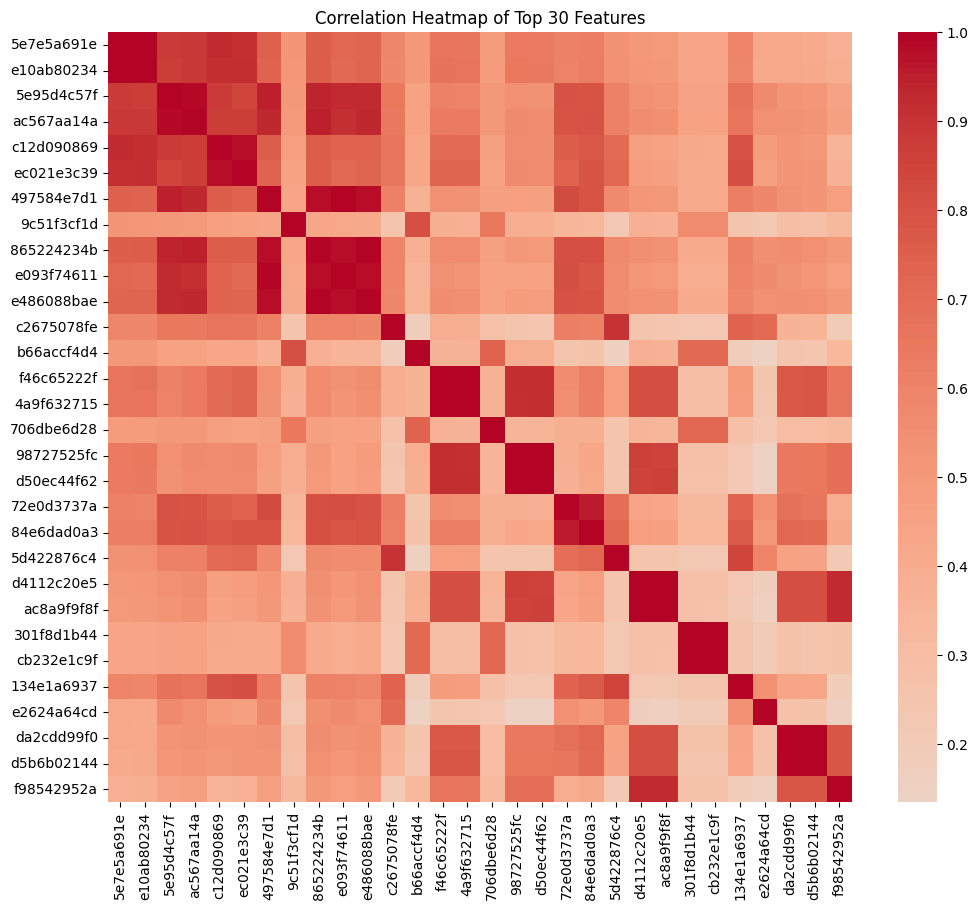

In [9]:
# Select top 30 features ranked by absolute IC
top30 = ic_table.sort_values("max_abs_ic", ascending=False).head(30).index

# Compute feature correlation matrix
corr_matrix = df[top30].corr()

# Visualize correlations heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top 30 Features")
plt.show()

The heatmap reveals that many of the top predictive features are highly correlated with each other, forming several clusters of similar signals. This indicates that multiple features may be capturing the same underlying market dynamics. If highly correlated features are used together in a model, there may be redundant information, which can lead to unstable model coefficients and reduced interpretability.

To construct a more robust feature set, we apply a correlation filtering step, where highly correlated features are reduced to a smaller set of representative feature. This helps ensure that the final feature set retains predictive power while avoiding unnecessary redundancy.

### Filtering Features

We group features that have pairwise correlation greater than 0.9. Within each correlated group, we retain only the feature with the highest predictive power (highest absolute IC). This ensures that we keep the most informative feature while removing redundant signals. This process results in a smaller set of relatively independent predictors for model construction.

In [10]:
# Threshold 0.9 for highly correlated features
threshold = 0.9
clusters = []
visited = set()

# Group features that are highly correlated
for feat in top30:
    if feat in visited:
        continue
    group = corr_matrix.index[corr_matrix[feat] > threshold].tolist()
    clusters.append(group)
    visited.update(group)

# From each cluster, keep the feature with highest IC
selected_features = []
for group in clusters:
    best = ic_table.loc[group, "max_abs_ic"].idxmax()
    selected_features.append(best)

print("Clusters:", len(clusters))
selected_df = pd.DataFrame({"selected_feature": selected_features})
selected_df

Clusters: 14


,selected_feature
0,5e7e5a691e
1,5e95d4c57f
2,9c51f3cf1d
3,c2675078fe
4,b66accf4d4
5,f46c65222f
6,706dbe6d28
7,72e0d3737a
8,5d422876c4
9,d4112c20e5


After applying the correlation filtering step, the feature set is reduced from 30 to **14 features**. We retain a subset of features that are both predictive and relatively independent, reducing redundancy in the feature space.

These selected features will be used in the following steps to construct composite trading signals and evaluate their predictive performance.

# Part 2: Prediction Horizon Analysis

In this section, we analyze how the predictive strength of the selected features behaves across different prediction horizons. The effectiveness of a feature depends on the time horizon over which predictions are made. These features tend to have short-lived predictive power, which may decay as the prediction horizon increases. To investigate this behaviour, we evaluate the IC of the selected features across several prediction horizons (1s, 5s, 10s, 30s, and 60s).

This analysis helps us:
- Understand signal decay behavior as the prediction horizon increases.
- Determine whether the signals capture very short-term microstructure effects or more persistent dynamics.
- Identify an appropriate prediction horizon for constructing trading signals.

By examining how IC values change across horizons, we can select a horizon that balances predictive strength and signal persistence.

### IC Decay for Individual Feature

                  1s        5s       10s       30s       60s  max_abs_ic
5e7e5a691e  0.209194  0.116485  0.078534  0.039725  0.028027    0.209194
5e95d4c57f  0.202927  0.111934  0.073664  0.034574  0.024227    0.202927
9c51f3cf1d  0.178774  0.119425  0.082537  0.036275  0.023543    0.178774
c2675078fe  0.162553  0.074796  0.043510  0.016844  0.011861    0.162553
b66accf4d4  0.159928  0.115950  0.085679  0.042486  0.029711    0.159928
f46c65222f  0.159504  0.089819  0.060832  0.028483  0.019115    0.159504
706dbe6d28  0.154287  0.099629  0.067709  0.025457  0.012441    0.154287
72e0d3737a  0.149613  0.074063  0.041765  0.007788  0.004447    0.149613
5d422876c4  0.142298  0.063506  0.036109  0.011630  0.008519    0.142298
d4112c20e5  0.140428  0.086430  0.060239  0.026453  0.018201    0.140428
301f8d1b44  0.127220  0.081491  0.055767  0.021994  0.011475    0.127220
134e1a6937  0.126948  0.047378  0.024038  0.005212  0.002651    0.126948
e2624a64cd  0.126852  0.060351  0.034174  0.013017 

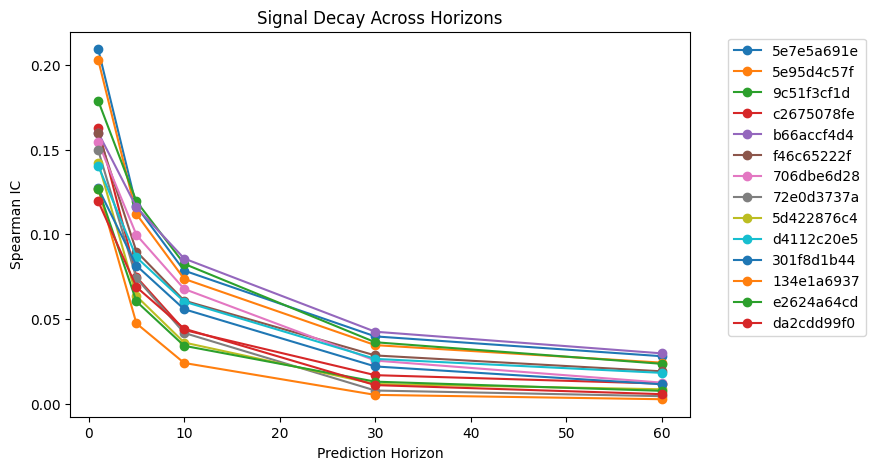

In [11]:
# Extract IC values of the selected features
selected_ic = ic_table.loc[selected_features]

# Display IC table for the selected features
print(selected_ic)

# Plot how predictive power (IC) changes across time horizons
plt.figure(figsize=(8,5))
for feat in selected_features:
    plt.plot(horizons, selected_ic.loc[feat, [f'{h}s' for h in horizons]], marker="o", label=feat)
plt.xlabel("Prediction Horizon")
plt.ylabel("Spearman IC")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Signal Decay Across Horizons")
plt.show()

The plot above shows how the predictive power of the selected features changes as the prediction horizon increases. Several observations can be made:
- The strongest predictive power appears at the shortest horizon (1s), where IC values range roughly between 0.12 and 0.21 across features.
- As the prediction horizon increases, the IC values consistently decline, indicating that the predictive signals decay over time.
- The drop in IC from 1s to 5s is particularly large, suggesting that a large portion of the signal reflects very short-term market microstructure effects.
- Beyond 10s, the IC values continue to decrease and become relatively small by 30s–60s, indicating limited predictive power at longer horizons.

These results show that the predictive information is strongest at short horizons and gradually dissipates as new market information arrives.

### Average IC Across Features

To obtain a clearer view of the overall signal strength, we compute the average IC across selected features at each prediction horizon.
This provides us with a summary measure of how predictive power decays as the horizon increases.

1s     0.154284
5s     0.086436
10s    0.056346
30s    0.022922
60s    0.014818
dtype: float64


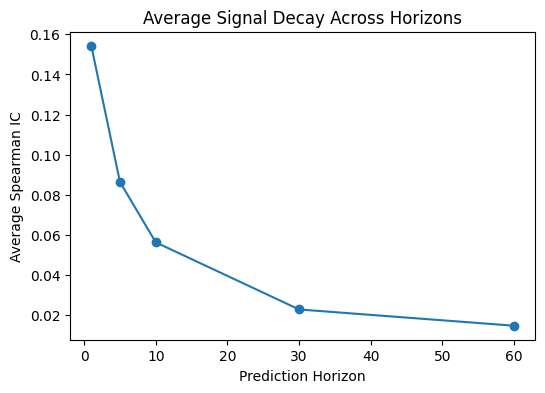

In [12]:
# Calculate average IC for each time horizon
avg_ic = selected_ic[[f'{h}s' for h in horizons]].mean()

# Display average IC table
print(avg_ic)

# Plot average IC across time horizons
plt.figure(figsize=(6,4))
plt.plot(horizons, avg_ic, marker="o")
plt.xlabel("Prediction Horizon")
plt.ylabel("Average Spearman IC")
plt.title("Average Signal Decay Across Horizons")
plt.show()

The results show the same pattern, predictive power is strongest at the shortest horizon (1s) and declines steadily as the prediction horizon increases. This confirms that most of the selected features primarily capture short term market dynamics, with predictive information decaying relatively quickly over time.

By averaging across features, this analysis highlights the overall signal decay profile, making it easier for us to compare predictive strength across horizons and identify a suitable horizon for model construction.

### Optimal Horizon Selection

The analysis above shows that predictive power is strongest at the shortest horizon of 1s and declines rapidly as the prediction horizon increases. However, selecting the horizon with the highest IC might not be optimal. Although the 1s horizon exhibits the strongest predictive power, an extremely short horizons are often dominated by market microstructure noise and may be difficult to trade in practice due to latency, execution delays, or transaction costs. The 5s horizon still demonstrates relatively strong predictive power, but the signals remain highly short-lived and might still be sensitive to microstructure effects.

From the signal decay plots, the decay begins to flatten around the 10s horizon. Up to this point, predictive power declines rapidly, but beyond 10s the rate of decay becomes much slower. This suggests that the most meaningful predictive information is captured within the first several seconds, while longer horizons add little additional predictive strength.

Therefore, the 10s horizon provides a reasonable trade off:
- It still retains meaningful predictive power.
- The signal decay becomes more stable compared to shorter horizons.
- It is less sensitive to microstructure noise than shorter horizons.

Beyond 30s, the IC values become relatively small, indicating that most predictive information has already dissipated. Based on these considerations, we select the **10-second horizon** as the prediction target for constructing composite trading signals.

# Part 3: Prediction Model Construction 

We selected the 10-second horizon and identified 14 candidate features with relatively strong and stable IC values.

Now, the goal is to combine these individual features into a composite predictive signal. Combining multiple predictive features can often produce a stronger and more stable signal than relying on any single feature alone. To construct the composite signal, we compare several approaches:

- **Best single feature**: Serves as a baseline to measure whether combining features actually improves predictive power.  
- **Equal-weight composite**:  Assumes all selected features contribute equally.  
- **IC-weighted composite**: Weights each feature according to its predictive strength measured by IC.  
- **Linear regression**: Learns optimal feature weights directly from the data.  
- **Ridge regression**: Introduces regularization to stabilize coefficients when features are correlated.  
- **Lasso regression**: Applies stronger regularization that can also perform feature selection.

All models are evaluated using out-of-sample IC and daily IC statistics, which measure the rank correlation between predicted signals and future returns.

### Model Construction & Comparison

We first create a dataset that contains all necessary inputs. The dataset includes:
- **14 selected predictive features**.
- **target variable (`ret_10s`)**, representing the 10-second future return.
- **date column**, which will later be used for daily IC analysis and regime analysis.

Rows with missing values are removed to ensure that all candidate signals are evaluated on a consistent dataset.

In [13]:
df = df.copy()
target_col = "ret_10s"
features = selected_features.copy()

# Make a copy of only the selected features, target, and date column
model_df = df[features + [target_col, "date"]].dropna().copy()

# 1. Best single feature
# Select the feature with the highest absolute IC at the 10s horizon
best_single_10s = ic_table.loc[features, "10s"].abs().idxmax()
model_df["best_single_10s"] = model_df[best_single_10s]

# 2. Equal-weight composite
# Simple average of all selected features
model_df["equal_weight_10s"] = model_df[features].mean(axis=1)

# 3. IC-weighted composite
# Weight each feature by its 10s IC, normalized by absolute weight sum
weights_10s = ic_table.loc[features, "10s"].copy()
weights_10s = weights_10s / weights_10s.abs().sum()
model_df["ic_weighted_10s"] = model_df[features].dot(weights_10s)


# Train-test split
# Use the first 70% for training and the last 30% for out-of-sample evaluation
split = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split].copy()
test_df  = model_df.iloc[split:].copy()

X_train = train_df[features]
X_test  = test_df[features]
y_train = train_df[target_col]
y_test  = test_df[target_col]

# 4. Linear regression
# Learn a linear combination of features from the training set
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
test_df["linear_pred_10s"] = linear_model.predict(X_test)

# 5. Ridge regression
# Add L2 regularization to reduce coefficient instability
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
test_df["ridge_pred_10s"] = ridge_model.predict(X_test)

# 6. Lasso regression
# Add L1 regularization to encourage sparse feature selection
lasso_model = Lasso(alpha=1e-5, max_iter=10000)
lasso_model.fit(X_train, y_train)
test_df["lasso_pred_10s"] = lasso_model.predict(X_test)

# Also copy non-model signals into test_df for fair comparison
test_df["best_single_10s"]   = test_df[best_single_10s]
test_df["equal_weight_10s"]  = test_df["equal_weight_10s"]
test_df["ic_weighted_10s"]   = test_df["ic_weighted_10s"]


def evaluate_signal(data, signal_col, target_col, date_col="date"):
    """
    Evaluate one signal using:
    - test set IC
    - mean daily IC
    - std daily IC
    - IC IR
    """
    tmp = data[[signal_col, target_col, date_col]].dropna().copy()
    test_set_ic = spearmanr(tmp[signal_col], tmp[target_col], nan_policy="omit")[0]
    daily_ic = tmp.groupby(date_col).apply(lambda x: spearmanr(x[signal_col], x[target_col], nan_policy="omit")[0], include_groups=False)
    mean_daily_ic = daily_ic.mean()
    std_daily_ic = daily_ic.std()
    ic_ir = mean_daily_ic / std_daily_ic if std_daily_ic != 0 else np.nan

    return {
        "signal": signal_col,
        "test_set_ic": test_set_ic,
        "mean_daily_ic": mean_daily_ic,
        "std_daily_ic": std_daily_ic,
        "ic_ir": ic_ir
    }

# Compare all candidate signals on the test set
signal_cols_10s = ["best_single_10s", "equal_weight_10s", "ic_weighted_10s", "linear_pred_10s", "ridge_pred_10s", "lasso_pred_10s"]

results_10s = []
for col in signal_cols_10s:
    results_10s.append(evaluate_signal(test_df, col, target_col, date_col="date"))
comparison_10s = pd.DataFrame(results_10s).sort_values(by="mean_daily_ic", ascending=False).reset_index(drop=True)

print("10s Time Horizon Comparison Table (Test Set)")
display(comparison_10s.style.format({ "test_set_ic": "{:.6f}", "mean_daily_ic": "{:.6f}", "std_daily_ic": "{:.6f}", "ic_ir": "{:.6f}"}))

10s Time Horizon Comparison Table (Test Set)


,signal,test_set_ic,mean_daily_ic,std_daily_ic,ic_ir
0,linear_pred_10s,0.070757,0.102603,0.061535,1.667382
1,ridge_pred_10s,0.070757,0.102603,0.061535,1.667388
2,lasso_pred_10s,0.065665,0.095628,0.057777,1.655127
3,best_single_10s,0.055871,0.086768,0.059712,1.453111
4,ic_weighted_10s,0.062294,0.084876,0.042947,1.976327
5,equal_weight_10s,0.058465,0.078688,0.038273,2.055962


We can observe several findings from the results:

- Linear regression and ridge regression achieve the strongest performance. Both models produce the highest full-sample IC and daily IC statistics. Their results are identical, suggesting that regularization in ridge does not significantly change the learned coefficients.
- Lasso regression performs slightly worse. Although lasso introduces sparsity by shrinking some coefficients toward zero, this regularization slightly reduces predictive power in this dataset.
- Simple composite methods (equal-weight and IC-weighted) perform reasonably well but remain weaker than regression-based models. These approaches combine features using fixed rules rather than learning optimal weights from the data.
- The best single feature performs the worst among the candidates. This indicates that combining multiple predictive signals provides additional information more than any individual feature.

We can conclude that linear regression provide a more effective way to combine features into a composite signal. To further understand how well the regression models fit the data and whether they generalize properly, we next examine their R² values on both the training and test sets.

### R² Calculation

It is also useful to examine the R² of the regression models. It provides a view of how well the regression models capture the relationship between the selected features and the future returns. Here, we use R² to compare the relative explanatory power of the regression models, check whether the models generalize well from the training set to the test set, and detect potential overfitting. R² values might be very small because returns are dominated by noise. Therefore, we use R² mainly as a diagnostic measure rather than the primary performance metric. We calculate R² for linear, ridge, and lasso regression on both the training and test datasets.

In [14]:
# Linear regression
r2_train_linear = r2_score(y_train, linear_model.predict(X_train))
r2_test_linear = r2_score(y_test, linear_model.predict(X_test))

# Ridge regression
r2_train_ridge = r2_score(y_train, ridge_model.predict(X_train))
r2_test_ridge = r2_score(y_test, ridge_model.predict(X_test))

# Lasso regression
r2_train_lasso = r2_score(y_train, lasso_model.predict(X_train))
r2_test_lasso = r2_score(y_test, lasso_model.predict(X_test))

# Display R² calculation
r2_results = pd.DataFrame({"Model": ["Linear", "Ridge", "Lasso"], "Train R2": [r2_train_linear, r2_train_ridge, r2_train_lasso],
                           "Test R2": [r2_test_linear, r2_test_ridge, r2_test_lasso]})

display(r2_results)

,Model,Train R2,Test R2
0,Linear,0.006960,0.002555
1,Ridge,0.006960,0.002555
2,Lasso,0.004772,0.002036


All regression models achieve small but positive explanatory power on both the training and test datasets. Several observations can be made:

- Linear and ridge regression produce identical R² values. This suggests that the selected features are not highly unstable or excessively correlated, so the regularization in ridge does not significantly alter the model.
- Lasso regression shows lower R². This occurs because lasso imposes stronger regularization by shrinking some coefficients toward zero, which reduces model complexity but may also remove some predictive information.
- The models generalize reasonably well and do not show clear signs of severe overfitting.

The result supports the earlier linear and ridge regression remain the strongest candidates for constructing the composite signal. 

### Regression Model Coefficient Analysis

We further examine each regression model coefficients, which represent the relative contribution of each feature to the predicted signal. Feature with larger absolute coefficient will have a stronger influence. Since ridge regression applies L2 regularization, which stabilizes coefficients when feature are correlated, and lasso regression applies L1 regularization, which can shrink coefficients to 0, comparing coefficients across model can also reveal how the regularizations affect the weights. We can also know which features are more important than the others.

In [15]:
# Coefficientse for each regression method
linear_coef = linear_model.coef_
ridge_coef = ridge_model.coef_
lasso_coef = lasso_model.coef_

# Display coefficients for all 14 features
coef_df = pd.DataFrame({"feature": X_train.columns, "linear_coef": linear_model.coef_, "ridge_coef": ridge_model.coef_, "lasso_coef": lasso_model.coef_})
display(coef_df)

,feature,linear_coef,ridge_coef,lasso_coef
0,5e7e5a691e,1.680969e-07,1.683968e-07,0.000004
1,5e95d4c57f,1.769155e-05,1.769092e-05,0.000001
2,9c51f3cf1d,-7.241233e-07,-7.239414e-07,0.000000
3,c2675078fe,3.496857e-06,3.496944e-06,0.000000
4,b66accf4d4,2.047247e-05,2.047216e-05,0.000009
5,f46c65222f,3.976210e-06,3.976043e-06,0.000000
6,706dbe6d28,-3.707615e-06,-3.707554e-06,0.000000
7,72e0d3737a,-4.801743e-06,-4.801441e-06,0.000000
8,5d422876c4,1.082892e-06,1.082753e-06,0.000000
9,d4112c20e5,-1.783143e-06,-1.782790e-06,0.000000


- Linear and ridge regression produce very similar coefficient values. This suggests that multicollinearity is not severe enough to affect the learned weights. The ridge regularization only has minimal impact on the learned weights.
- Lasso regression shrinks most of the coefficients to 0, resulting in only 3 important features.

### Feature Selection Refinement

From the previous model comparisons, linear and ridge demonstrate the strongest predictive performance, while lasso showed a weaker IC and R² value. Also, since linear and ridge regression produces nearly identical results, we will proceed with linear regression for further analysis because it provides a simpler and more interpretable model.

Next, we investigate whether reducing the number of features can improve model robustness while maintaining performance. The absolute magnitude of linear regression coefficients are used to measure feature importance. The intuition is that larger coefficient means feature contribute stronger to the prediction. We compare linear regression models built by using different features subset:
- Full set of 14 selected features.
- Top 10 features from linear regression.
- Top 7 features from linear regression.
- Top 5 features from linear regression.
- 3 features selected by lasso regression.

In [16]:
# 5, 7, 10 features from linear regression 
coef_df["abs_linear"] = coef_df["linear_coef"].abs() 
ranked_features = coef_df.sort_values("abs_linear", ascending=False)["feature"].tolist() 
top5 = ranked_features[:5] 
top7 = ranked_features[:7] 
top10 = ranked_features[:10]

# Features selected from lasso regression
lasso_selected_features = coef_df[coef_df["lasso_coef"] != 0]["feature"].tolist()

# Build a feature set
feature_sets = {"linear_14f": selected_features,
                "linear_10f": top10,
                "linear_7f": top7,
                "linear_5f": top5,
                "linear_3f_lasso": lasso_selected_features}

rows = []
for name, feat_list in feature_sets.items():
    # Fit model
    model = LinearRegression()
    model.fit(train_df[feat_list], train_df[target_col])

    # Train and test set predictions
    train_pred = model.predict(train_df[feat_list])
    test_pred = model.predict(test_df[feat_list])

    # Save prediction to test_df for IC evaluation
    test_df[name] = test_pred

    # R² calculation
    train_r2 = r2_score(train_df[target_col], train_pred)
    test_r2 = r2_score(test_df[target_col], test_pred)

    # IC evaluation
    ic_stats = evaluate_signal(test_df, name, target_col, date_col="date")

    rows.append({"model": name,
                "n_features": len(feat_list),
                "train_r2": train_r2,
                "test_r2": test_r2,
                "test_set_ic": ic_stats["test_set_ic"],
                "mean_daily_ic": ic_stats["mean_daily_ic"],
                "std_daily_ic": ic_stats["std_daily_ic"],
                "ic_ir": ic_stats["ic_ir"]})

# Sort by descending mean_daily_ic values
feature_refinement_results = pd.DataFrame(rows).sort_values(by="mean_daily_ic", ascending=False).reset_index(drop=True)

# Display comparison table
print("Feature Selection Refinement Comparison (Test Set)")
display(feature_refinement_results.style.format({
        "train_r2": "{:.6f}",
        "test_r2": "{:.6f}",
        "test_set_ic": "{:.6f}",
        "mean_daily_ic": "{:.6f}",
        "std_daily_ic": "{:.6f}",
        "ic_ir": "{:.6f}"}))

Feature Selection Refinement Comparison (Test Set)


,model,n_features,train_r2,test_r2,test_set_ic,mean_daily_ic,std_daily_ic,ic_ir
0,linear_10f,10,0.006957,0.002510,0.070842,0.102696,0.061576,1.667779
1,linear_14f,14,0.006960,0.002555,0.070757,0.102603,0.061535,1.667382
2,linear_5f,5,0.006698,0.002363,0.068876,0.101753,0.063658,1.598421
3,linear_7f,7,0.006765,0.002420,0.069160,0.101464,0.062515,1.623032
4,linear_3f_lasso,3,0.006166,0.002778,0.066383,0.097784,0.060593,1.613776


### Composite Signal Selection

The results show that the 10 feature model achieves the highest IC. Although it has a lower R² compared to the full 14 feature model and the lasso selected feature model, this is not a major concern, the 10 feature model provides the strongest predictive ranking performance while using a more compact feature set. This balance between predictive strength and model simplicity makes the 10 feature model an appropriate choice for the final signal. Also, since R² values are typically small due to the high level of noise in returns, it is mainly used as a diagnostic metric, while our primary objective is to maximize the model's ability to correctly rank future returns.

Since trading strategies rely on ranking assets or signals rather than precisly predicting return magnitudes, the IC here is the more relevant evaluation metric for this task. The 10 feature model therefore offers a good balance between strong predictive performance, reduced model complexity, and stable regression fit. Based on these considerations, we select the final configuration:

- **Final Model**: Linear Regression
- **Prediction Horizon**: 10 seconds
- **Feature Set**: Top 10 features ranked by coefficient magnitude

Below, we display the final 10 features selected from linear regression.

In [24]:
# Display the 10 features used in final linear regression model
final_10f = pd.DataFrame({"final_selected_feature": top10})
final_10f

,final_selected_feature
0,b66accf4d4
1,5e95d4c57f
2,134e1a6937
3,72e0d3737a
4,301f8d1b44
5,f46c65222f
6,706dbe6d28
7,c2675078fe
8,e2624a64cd
9,d4112c20e5


# Part 4: Regime or Stability Analysis

After constructing the composite trading signal, the next step is to evaluate its robustness and stability. A useful trading signal should maintain consistent performance across time and different market conditions. Signals that perform well only during specific periods may indicate regime sensitivity, which can reduce reliability in live trading environments. Therefore, it is important to examine whether the predictive relationship between the signal and future returns remains stable or varies across different market conditions.

To investigate this, we conduct several analysis:

1. **Rolling IC Analysis**: Measures the correlation between the signal and future returns over a rolling time window. This assesses whether predictive performance is consistent through time or concentrated in specific periods.
2. **Daily IC Analysis**: Computes IC for each trading day. This allows us to examine the distribution and variability of daily predictive performance.
3. **Quantile Return Analysis**: Sorts observations by signal value and compares the average future returns across quantiles. A strong signal should produce monotonic returns, where higher signal values correspond to higher future returns.
4. **Regime Analysis**: Evaluates signal performance under different market conditions (ex: high vs low volatility). This helps determine whether the signal behaves differently across market regimes.

The following analysis are conducted on full-sample fitted predictions, so they are more of descriptive diagnostics rather than strict out-of-sample validation.

In [18]:
# Final composite signal: Linear regression on 10 selected features with 10s horizon
# Retrain the final model on the full dataset
model_df = df[top10 + ["ret_10s"]].dropna().copy()

X_full = model_df[top10]
Y_full = model_df["ret_10s"]

final_model = LinearRegression()
final_model.fit(X_full, Y_full)

# Generate final signal predictions
model_df["final_signal_10s"] = final_model.predict(X_full)

### Rolling IC Analysis

Instead of computing a single IC for the entire dataset, we approximate rolling rank IC by computing rolling correlation on globally ranked signal and return series. This allows us to observe whether the signal maintains consistent predictive power or if its performance varies across different periods.
A stable signal should produce consistently positive rolling IC values, while large fluctuations or persistent negative periods may indicate instability or regime sensitivity. In this analysis, we use a 30 minute rolling window (1800 observations) to compute the rolling IC between the final signal and the 10 second future returns.

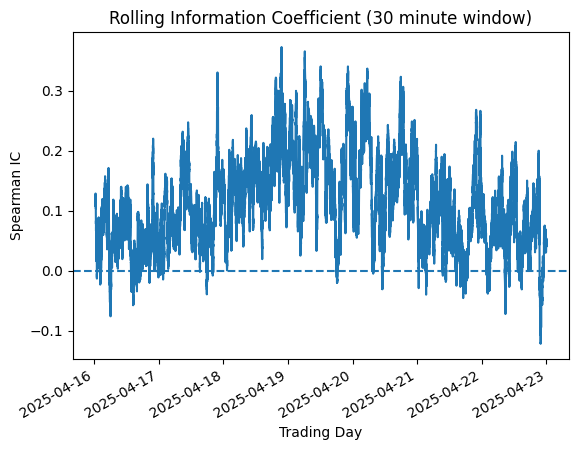

In [19]:
# A 30 minute rolling window (1800 observations) is used to balance responsiveness and statistical stability when estimating the rolling IC
window = 1800

# Compute rolling correlation between signal and return
# Since Spearman correlation is equivalent to the Pearson correlation of ranked variables, 
# we compute rolling rank IC by applying rolling correlation to globally ranked signal and return series.
signal_rank = model_df["final_signal_10s"].rank()
ret_rank = model_df["ret_10s"].rank()
rolling_ic = signal_rank.rolling(window).corr(ret_rank)

# Plot rolling IC over time
rolling_ic.plot()
plt.axhline(0, linestyle="--")
plt.xlabel("Trading Day")
plt.ylabel("Spearman IC")
plt.title("Rolling Information Coefficient (30 minute window)")
plt.show()

The rolling IC plot shows how the predictive relationship between the signal and future returns evolves over time. The signal maintains mostly positive IC values throughout the sample period, indicating that the predictive relationship remains generally consistent. While the IC fluctuates across time, this behaviour is expected due to market noise and changing microstructure conditions. More importantly, the rolling IC rarely stays negative for extended periods, suggesting that the signal does not lose predictive power persistently.

We also observe a period around April 18–20 where the IC reaches relatively higher levels, indicating that the signal was particularly effective during that time interval. After this period, the IC declines slightly but continues to remain mostly positive.

We can conclude that the signal exhibits moderate stability over time. Although predictive strength varies across different periods, the signal does not appear to rely on a single regime, indicating that the predictive relationship is reasonably persistent.

### Daily IC Analysis

Daily IC provides a view of signal stability across different days. By computing the IC separately for each day, we can examine whether the signal consistently produces positive predictive power or if performance is concentrated in only a few days.

Daily IC:
2025-04-16    0.056832
2025-04-17    0.090317
2025-04-18    0.144789
2025-04-19    0.170445
2025-04-20    0.153171
2025-04-21    0.072466
2025-04-22    0.062205
dtype: float64


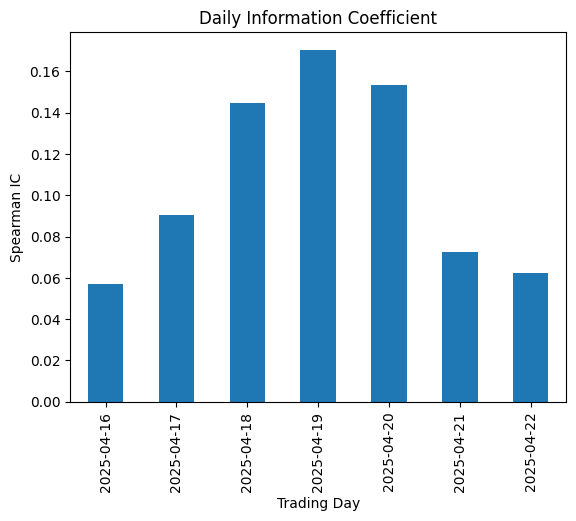

In [20]:
# Compute IC separately for each trading day
daily_ic = model_df.groupby(model_df.index.date).apply(lambda x: spearmanr(x["final_signal_10s"], x["ret_10s"]).correlation)

# Display daily IC
print("Daily IC:")
print(daily_ic)

# Display daily IC plot
daily_ic.plot(kind="bar")
plt.xlabel("Trading Day")
plt.ylabel("Spearman IC")
plt.title("Daily Information Coefficient")
plt.show()

The daily IC results provide a clearer view of how the signal performs on each trading day. We observe that the IC values are positive on every trading day. The strongest performance occurs around April 18–20, where daily IC values exceed 0.10, suggesting that the signal was particularly effective during those days. On the other days, the IC values remain positive but lower, generally ranging between 0.06 and 0.09. This variation exists because market conditions, liquidity, and order flow dynamics can change across days. Also, none of the days exhibit strongly negative IC values, indicating that the signal does not lose predictive ability under normal market conditions.

The daily IC analysis suggests that the signal demonstrates consistent directional predictive power across trading days, with moderate variation in strength rather than abrupt regime shifts.

### Quantile Return Analysis

Quantile return analysis evaluates whether the signal correctly ranks future returns. The observations are first sorted based on the predicted signal value and divided into 10 equal-sized quantiles. For each quantile, we compute the average future return.

If the signal has predictive power, we can expect a monotonic relationship:
- Lower signal quantiles should correspond to lower future returns.
- Higher signal quantiles should correspond to higher future returns.

signal_q
0   -0.000041
1   -0.000031
2   -0.000016
3   -0.000011
4   -0.000001
5    0.000008
6    0.000010
7    0.000023
8    0.000030
9    0.000046
Name: ret_10s, dtype: float32


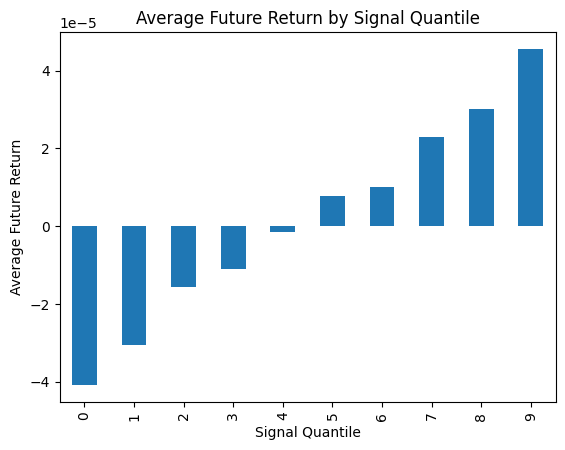

In [21]:
# Divide observations into 10 quantiles based on the signal value
model_df["signal_q"] = pd.qcut(model_df["final_signal_10s"], 10, labels=False)

# Compute the average future return for each quantile
quantile_returns = model_df.groupby("signal_q")["ret_10s"].mean()
print(quantile_returns)

# Plot mean return by signal quantile
quantile_returns.plot(kind="bar")
plt.xlabel("Signal Quantile")
plt.ylabel("Average Future Return")
plt.title("Average Future Return by Signal Quantile")
plt.show()

Observations are sorted by the signal value and divided into ten equal-sized quantiles, after which the average future return is computed for each group. The resulting plot shows a clear monotonic relationship between the signal value and future returns. Lower signal quantiles produce negative average returns, while higher signal quantiles produce positive average returns. In particular, the highest quantile generates the largest positive returns, while the lowest quantile produces the most negative returns.

This structure indicates that the signal successfully rank observations according to expected future price movements. It allows us to take long positions in high signal observations and short positions in low signal observations. The smooth progression of returns across quantiles also supports the earlier IC results, which suggested that the signal has a consistent positive relationship with future returns.

This analysis provides evidence that the signal captures meaningful predictive information and produces a reasonable ranking of future returns.

### Regime Analysis

We define market regimes based on realized volatility. Volatility is estimated using a rolling standard deviation of 1 second returns over a 300 observation window.
The dataset is then divided into two regimes:

- High volatility regime: Observations where volatility is above the median.
- Low volatility regime: Observations where volatility is below or equal to the median.  

We then compute IC of the signal within each regime to determine whether the signal performs differently under different market environments.

In [22]:
# Estimate short-term realized volatility using rolling std of 1s returns
df["volatility"] = df["ret_1s"].rolling(300).std()

# Use median volatility to split regimes
median_vol = df["volatility"].median()

# Define high and low volatility
high_vol = model_df.loc[df["volatility"] > median_vol]
low_vol  = model_df.loc[df["volatility"] <= median_vol]

# Calculate IC of the signal in each regime
ic_low = spearmanr(low_vol["final_signal_10s"], low_vol["ret_10s"]).correlation 
ic_high = spearmanr(high_vol["final_signal_10s"], high_vol["ret_10s"]).correlation

print("High Volatility IC:", ic_high)
print("Low Volatility IC:", ic_low)

High Volatility IC: 0.05785244195440939
Low Volatility IC: 0.16250469136287055


The results show a clear difference between the two regimes. In the low volatility regime, the signal achieves an IC of approximately 0.162, indicating strong predictive power. On the other hand, the IC drops to around 0.058 in the high volatility regime, suggesting that the signal becomes less effective when market volatility increases.

This indicates that the signal performs more reliably when market conditions are relatively stable. During periods of higher volatility, rapid price movements and increased market noise might weaken the relationship between the signal and future returns, making it more difficult for the signal to accurately rank future price changes.

### Stationarity or Regime Sensitivity

Looking at the analysis we conducted, the signal demonstrates reasonably stable predictive power across time, as indicated by both the rolling IC and daily IC analysis. The signal maintains mostly positive correlations with future returns and consistently ranks observations effectively, as shown by the quantile return analysis.

However, the regime analysis reveals that the signal’s predictive strength varies across market conditions. In particular, the IC during low volatility period is significantly higher than during high volatility period, indicating that the signal performs more effectively when market conditions are relatively stable.

Taken together, these results suggest that while the signal exhibits overall stability, it is not fully stationary. Instead, the signal shows moderate regime sensitivity, with predictive performance varying across different volatility environments.

### Potential Improvements

Given the observed regime sensitivity, several improvements could be considered to improve the robustness of the signal:

1. **Volatility Filtering**: Since the signal exhibits stronger predictive power during low volatility periods, one simple improvement would be to apply a volatility filter. For example, the strategy could generate trading signals when realized volatility is below a certain threshold. This would help avoid trading during noisy high volatility regimes where the signal is less reliable.

2. **Volatility-Scaled Position Sizing**: Instead of completely disabling the signal during high volatility periods, position sizes could be adjusted according to the volatility regime. For example, the strategy could reduce exposure when volatility is high and increase exposure when volatility is low, reflecting the observed difference in predictive strength.

3. **Regime-Specific Thresholds**: Another enhancement would be to apply different signal thresholds depending on the volatility regime. For instance, stronger signal values could be required to trigger trades during high volatility periods, helping filter out weaker predictions.

These improvements could help make the signal more robust across different market environments and improve its practical applicability in trading strategies.